In [261]:
import io
import warnings
import torch

from pathlib import Path
from pprint import pprint
from fairseq import checkpoint_utils, options, tasks
from contextlib import redirect_stdout, redirect_stderr
from utils import REPO_ROOT, preprocess_mask_predict_data, trace_mask_predict_iterations

In [262]:
prep_result = preprocess_mask_predict_data(
    input_dir=REPO_ROOT / "input",
    output_dir=REPO_ROOT / "output",
    model_dir=REPO_ROOT / "checkpoints" / "maskPredict_en_de",
    source_lang="en",
    target_lang="de",
    run_name="en_de_demo",
    workers=10,
)

In [263]:
trace_result = trace_mask_predict_iterations(
    data_bin_dir=prep_result["data_bin_dir"],
    output_dir=REPO_ROOT / "output",
    model_dir=REPO_ROOT / "checkpoints" / "maskPredict_en_de",
    source_lang="en",
    target_lang="de",
    subset="test",
    run_name="en_de_demo",
    decoding_iterations=5,
    length_beam=5,
    max_sentences=20,
)

for record in trace_result["records"]:
    print(f"[{record['id']}]")
    print("src:", record["source"])
    print("tgt:", record["target"])
    print("hyp:", record["hypothesis"])
    print("iterations:")
    for step in record["iterations"]:
        print(f"iter {step['iteration']:02d} (masked={step['masked_tokens']:>2}): {step['text']}")


[0]
src: The capital of France is Paris .
tgt: Die Hauptstadt Frankreichs ist Paris .
hyp: Die Hauptstadt Frankreichs ist Paris .
iterations:
iter 00 (masked= 0): Die Hauptstadt Frankreichs ist Paris .
iter 01 (masked= 5): Die Hauptstadt Frankreichs ist Paris .
iter 02 (masked= 4): Die Hauptstadt Frankreichs ist Paris .
iter 03 (masked= 2): Die Hauptstadt Frankreichs ist Paris .
iter 04 (masked= 1): Die Hauptstadt Frankreichs ist Paris .
[1]
src: The capital of Germany is Berlin .
tgt: Die Hauptstadt Deutschlands ist Berlin .
hyp: Die Hauptstadt Deutschlands ist Berlin .
iterations:
iter 00 (masked= 0): Die Hauptstadt Deutschlands ist Berlin .
iter 01 (masked= 5): Die Hauptstadt Deutschlands ist Berlin .
iter 02 (masked= 4): Die Hauptstadt Deutschlands ist Berlin .
iter 03 (masked= 2): Die Hauptstadt Deutschlands ist Berlin .
iter 04 (masked= 1): Die Hauptstadt Deutschlands ist Berlin .
[2]
src: China is a large country in Asia , and the capital of the country is Beijing .
tgt: China i

In [264]:
state = torch.load("./checkpoints/maskPredict_en_de/checkpoint_best.pt", map_location="cpu", weights_only=False)
model_args = state["args"]

for k in [
    "arch",
    "encoder_layers",
    "encoder_embed_dim",
    "encoder_ffn_embed_dim",
    "encoder_attention_heads",
    "decoder_layers",
    "decoder_embed_dim",
    "decoder_ffn_embed_dim",
    "decoder_attention_heads",
]:
    if hasattr(model_args, k):
        print(k, "=", getattr(model_args, k))


arch = bert_transformer_seq2seq
encoder_layers = 6
encoder_embed_dim = 512
encoder_ffn_embed_dim = 2048
encoder_attention_heads = 8
decoder_layers = 6
decoder_embed_dim = 512
decoder_ffn_embed_dim = 2048
decoder_attention_heads = 8


In [265]:
def get_encoder_output(sentence: str, data_bin_dir=prep_result["data_bin_dir"], model_dir=REPO_ROOT / "checkpoints" / "maskPredict_en_de", source_lang: str = "en", target_lang: str = "de"):
    data_bin_dir = Path(data_bin_dir)
    checkpoint_path = Path(model_dir) / "checkpoint_best.pt"
    cli_args = [
        str(data_bin_dir),
        "--path", str(checkpoint_path),
        "--task", "translation_self",
        "--source-lang", source_lang,
        "--target-lang", target_lang,
        "--remove-bpe",
        "--max-sentences", "20",
        "--decoding-iterations", "10",
        "--decoding-strategy", "mask_predict",
        "--length-beam", "5",
        "--gen-subset", "test",
        "--cpu",
    ]

    parser = options.get_generation_parser()
    args = options.parse_args_and_arch(parser, input_args=cli_args)

    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()), warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="FairseqModel is deprecated, please use FairseqEncoderDecoderModel or BaseFairseqModel instead",
            category=UserWarning,
        )
        task = tasks.setup_task(args)
        models, _ = checkpoint_utils.load_model_ensemble(
            args.path.split(":"),
            arg_overrides=eval(args.model_overrides),
            task=task,
        )

    model = models[0].cpu()
    model.eval()

    src_tokens = task.source_dictionary.encode_line(sentence, add_if_not_exist=False).long().unsqueeze(0)
    src_lengths = torch.LongTensor([src_tokens.size(1)])

    with torch.no_grad():
        encoder_out = model.encoder(src_tokens=src_tokens, src_lengths=src_lengths)

    return {
        "sentence": sentence,
        "src_tokens": src_tokens,
        "src_lengths": src_lengths,
        "encoder_out": {
            "encoder_out": encoder_out["encoder_out"].detach().cpu(),
            "encoder_padding_mask": None if encoder_out["encoder_padding_mask"] is None else encoder_out["encoder_padding_mask"].detach().cpu(),
            "predicted_lengths": encoder_out["predicted_lengths"].detach().cpu(),
        },
    }


In [266]:
encoder_example = get_encoder_output(
    "China is a large country in Asia , and the capital of the country is Beijing .",
)

print("sentence:", encoder_example["sentence"])
print("src_tokens shape:", tuple(encoder_example["src_tokens"].shape))
print("src_lengths:", encoder_example["src_lengths"].tolist())

sentence: China is a large country in Asia , and the capital of the country is Beijing .
src_tokens shape: (1, 18)
src_lengths: [18]


In [267]:
patch_src_sentence = "China is a large country in Asia , and the capital of the country is Beijing ."
patch_tgt_sentence = "Germany is a large country in Europe , and the capital of the country is Berlin ."

patch_src = get_encoder_output(patch_src_sentence)
patch_tgt = get_encoder_output(patch_tgt_sentence)

In [268]:
print("patch src sentence:", patch_src["sentence"])
print("patch tgt sentence:", patch_tgt["sentence"])

print("patch src encoder_out shape:", tuple(patch_src["encoder_out"]["encoder_out"].shape))
print("patch tgt encoder_out shape:", tuple(patch_tgt["encoder_out"]["encoder_out"].shape))

print("patch src token ids:", patch_src["src_tokens"].tolist())
print("patch tgt token ids:", patch_tgt["src_tokens"].tolist())

def patch_encoder_token(base_output, donor_output, token_position: int):
    base_encoder_out = base_output["encoder_out"]["encoder_out"].clone()
    donor_encoder_out = donor_output["encoder_out"]["encoder_out"]

    if token_position < 0 or token_position >= base_encoder_out.size(0) or token_position >= donor_encoder_out.size(0):
        raise IndexError(f"token_position {token_position} out of range for lengths {base_encoder_out.size(0)} and {donor_encoder_out.size(0)}")

    base_encoder_out[token_position, 0, :] = donor_encoder_out[token_position, 0, :]
    return {
        "sentence": base_output["sentence"],
        "src_tokens": base_output["src_tokens"].clone(),
        "src_lengths": base_output["src_lengths"].clone(),
        "encoder_out": {
            "encoder_out": base_encoder_out,
            "encoder_padding_mask": None if base_output["encoder_out"]["encoder_padding_mask"] is None else base_output["encoder_out"]["encoder_padding_mask"].clone(),
            "predicted_lengths": base_output["encoder_out"]["predicted_lengths"].clone(),
        },
    }


patch src sentence: China is a large country in Asia , and the capital of the country is Beijing .
patch tgt sentence: Germany is a large country in Europe , and the capital of the country is Berlin .
patch src encoder_out shape: (18, 1, 512)
patch tgt encoder_out shape: (18, 1, 512)
patch src token ids: [[625, 16, 15, 675, 444, 8, 4246, 5, 10, 7, 1924, 9, 7, 444, 16, 14672, 6, 2]]
patch tgt token ids: [[1013, 16, 15, 675, 444, 8, 199, 5, 10, 7, 1924, 9, 7, 444, 16, 1408, 6, 2]]


In [269]:
token_position = 3
patched_tgt = patch_encoder_token(patch_tgt, patch_src, token_position)

print("source sentence:", patch_tgt["sentence"])
print("target sentence:", patch_src["sentence"])
print("source token id at position:", patch_tgt["src_tokens"][0, token_position].item())
print("target token id at position:", patch_src["src_tokens"][0, token_position].item())


source sentence: Germany is a large country in Europe , and the capital of the country is Berlin .
target sentence: China is a large country in Asia , and the capital of the country is Beijing .
source token id at position: 675
target token id at position: 675


In [270]:
def text_of_token(encoder_output, token_position: int, dictionary_path=REPO_ROOT / "checkpoints" / "maskPredict_en_de" / "dict.en.txt"):
    from fairseq.data import Dictionary

    dictionary = Dictionary.load(str(dictionary_path))
    src_tokens = encoder_output["src_tokens"][0]

    if token_position < 0 or token_position >= src_tokens.shape[0]:
        raise IndexError(f"token_position {token_position} out of range for length {src_tokens.shape[0]}")

    token_id = src_tokens[token_position].item()
    return {
        "sentence": encoder_output["sentence"],
        "position": token_position,
        "token_id": token_id,
        "token": dictionary[token_id],
    }


In [271]:
def patch_encoder_layer_token_activation(src_sentence: str, tgt_sentence: str, layer_index: int, token_position: int, data_bin_dir=prep_result["data_bin_dir"], model_dir=REPO_ROOT / "checkpoints" / "maskPredict_en_de", source_lang: str = "en", target_lang: str = "de"):
    import torch.nn.functional as F

    data_bin_dir = Path(data_bin_dir)
    checkpoint_path = Path(model_dir) / "checkpoint_best.pt"
    cli_args = [
        str(data_bin_dir),
        "--path", str(checkpoint_path),
        "--task", "translation_self",
        "--source-lang", source_lang,
        "--target-lang", target_lang,
        "--remove-bpe",
        "--max-sentences", "20",
        "--decoding-iterations", "10",
        "--decoding-strategy", "mask_predict",
        "--length-beam", "5",
        "--gen-subset", "test",
        "--cpu",
    ]

    parser = options.get_generation_parser()
    args = options.parse_args_and_arch(parser, input_args=cli_args)

    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()), warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="FairseqModel is deprecated, please use FairseqEncoderDecoderModel or BaseFairseqModel instead",
            category=UserWarning,
        )
        task = tasks.setup_task(args)
        models, _ = checkpoint_utils.load_model_ensemble(
            args.path.split(":"),
            arg_overrides=eval(args.model_overrides),
            task=task,
        )

    model = models[0].cpu()
    model.eval()
    encoder = model.encoder

    if layer_index < 0 or layer_index >= len(encoder.layers):
        raise IndexError(f"layer_index {layer_index} out of range for {len(encoder.layers)} encoder layers")

    src_tokens = task.source_dictionary.encode_line(src_sentence, add_if_not_exist=False).long().unsqueeze(0)
    tgt_tokens = task.source_dictionary.encode_line(tgt_sentence, add_if_not_exist=False).long().unsqueeze(0)

    if token_position < 0 or token_position >= src_tokens.size(1) or token_position >= tgt_tokens.size(1):
        raise IndexError(f"token_position {token_position} out of range for src/tgt lengths {src_tokens.size(1)} and {tgt_tokens.size(1)}")

    def build_encoder_inputs(tokens):
        x = encoder.embed_tokens(tokens)
        if encoder.embed_positions is not None:
            x = x + encoder.embed_positions(tokens)
        len_tokens = encoder.embed_lengths(tokens.new(tokens.size(0), 1).fill_(0))
        x = torch.cat([len_tokens, x], dim=1)
        x = F.dropout(x, p=encoder.dropout, training=encoder.training)
        x = x.transpose(0, 1)
        padding_mask = tokens.eq(encoder.padding_idx)
        padding_mask = torch.cat([padding_mask.new(tokens.size(0), 1).fill_(0), padding_mask], dim=1)
        if not padding_mask.any():
            padding_mask = None
        return x, padding_mask

    src_x, src_padding_mask = build_encoder_inputs(src_tokens)
    tgt_x, tgt_padding_mask = build_encoder_inputs(tgt_tokens)
    patch_index = token_position + 1

    source_layer_activation = None
    target_layer_activation_before_patch = None
    patched_layer_activation = None

    for idx, layer in enumerate(encoder.layers):
        src_x = layer(src_x, src_padding_mask)
        tgt_x = layer(tgt_x, tgt_padding_mask)
        if idx == layer_index:
            source_layer_activation = src_x[patch_index, 0, :].detach().cpu().clone()
            target_layer_activation_before_patch = tgt_x[patch_index, 0, :].detach().cpu().clone()
            tgt_x[patch_index, 0, :] = src_x[patch_index, 0, :]
            patched_layer_activation = tgt_x[patch_index, 0, :].detach().cpu().clone()

    if encoder.normalize:
        src_x = encoder.layer_norm(src_x)
        tgt_x = encoder.layer_norm(tgt_x)

    def finalize_encoder_output(x, padding_mask):
        predicted_lengths_logits = torch.matmul(x[0, :, :], encoder.embed_lengths.weight.transpose(0, 1)).float()
        predicted_lengths_logits[:, 0] += float('-inf')
        predicted_lengths = F.log_softmax(predicted_lengths_logits, dim=-1)
        x = x[1:, :, :]
        if padding_mask is not None:
            padding_mask = padding_mask[:, 1:]
        return {
            "encoder_out": x.detach().cpu(),
            "encoder_padding_mask": None if padding_mask is None else padding_mask.detach().cpu(),
            "predicted_lengths": predicted_lengths.detach().cpu(),
        }

    patched_encoder_out = finalize_encoder_output(tgt_x, tgt_padding_mask)

    return {
        "src_sentence": src_sentence,
        "tgt_sentence": tgt_sentence,
        "layer_index": layer_index,
        "token_position": token_position,
        "src_tokens": src_tokens.detach().cpu(),
        "tgt_tokens": tgt_tokens.detach().cpu(),
        "source_layer_activation": source_layer_activation,
        "target_layer_activation_before_patch": target_layer_activation_before_patch,
        "patched_layer_activation": patched_layer_activation,
        "patched_encoder_out": patched_encoder_out,
    }


In [279]:
token_id = 0
layer_patch_result = patch_encoder_layer_token_activation(
    patch_src_sentence,
    patch_tgt_sentence,
    layer_index=3,
    token_position=token_id,
)

patched_final_vec = layer_patch_result["patched_encoder_out"]["encoder_out"][token_id, 0, :]
original_final_vec = patch_tgt["encoder_out"]["encoder_out"][token_id, 0, :]
src_token_info = text_of_token(patch_src, token_id)
tgt_token_info = text_of_token(patch_tgt, token_id)

print("layer index:", layer_patch_result["layer_index"])
print("token position:", layer_patch_result["token_position"])
print("src token:", src_token_info)
print("tgt token:", tgt_token_info)
print("patched final encoder_out shape:", tuple(layer_patch_result["patched_encoder_out"]["encoder_out"].shape))


layer index: 3
token position: 0
src token: {'sentence': 'China is a large country in Asia , and the capital of the country is Beijing .', 'position': 0, 'token_id': 625, 'token': 'China'}
tgt token: {'sentence': 'Germany is a large country in Europe , and the capital of the country is Berlin .', 'position': 0, 'token_id': 1013, 'token': 'Germany'}
patched final encoder_out shape: (18, 1, 512)


In [280]:
def decode_from_encoder_output(encoder_output, decoding_iterations: int = 5, data_bin_dir=prep_result["data_bin_dir"], model_dir=REPO_ROOT / "checkpoints" / "maskPredict_en_de", source_lang: str = "en", target_lang: str = "de"):
    from fairseq.strategies.strategy_utils import generate_step_with_prob

    data_bin_dir = Path(data_bin_dir)
    checkpoint_path = Path(model_dir) / "checkpoint_best.pt"
    cli_args = [
        str(data_bin_dir),
        "--path", str(checkpoint_path),
        "--task", "translation_self",
        "--source-lang", source_lang,
        "--target-lang", target_lang,
        "--remove-bpe",
        "--max-sentences", "20",
        "--decoding-iterations", str(decoding_iterations),
        "--decoding-strategy", "mask_predict",
        "--length-beam", "5",
        "--gen-subset", "test",
        "--cpu",
    ]

    parser = options.get_generation_parser()
    args = options.parse_args_and_arch(parser, input_args=cli_args)

    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()), warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="FairseqModel is deprecated, please use FairseqEncoderDecoderModel or BaseFairseqModel instead",
            category=UserWarning,
        )
        task = tasks.setup_task(args)
        models, _ = checkpoint_utils.load_model_ensemble(
            args.path.split(":"),
            arg_overrides=eval(args.model_overrides),
            task=task,
        )

    model = models[0].cpu()
    model.eval()
    tgt_dict = task.target_dictionary

    encoder_out = {
        "encoder_out": encoder_output["encoder_out"].clone(),
        "encoder_padding_mask": None if encoder_output["encoder_padding_mask"] is None else encoder_output["encoder_padding_mask"].clone(),
        "predicted_lengths": encoder_output["predicted_lengths"].clone(),
    }

    predicted_length = int(encoder_out["predicted_lengths"].argmax(dim=-1).item())
    predicted_length = max(2, predicted_length)
    tgt_tokens = torch.full((1, predicted_length), tgt_dict.mask(), dtype=torch.long)
    iterations = decoding_iterations if decoding_iterations is not None else predicted_length
    iteration_trace = []

    def record_iteration(iteration, tokens, probs, selected_mask_token_ids=None, selected_mask_scores=None):
        token_ids = tokens[0].detach().cpu()
        token_confidences = probs[0].detach().cpu()
        token_mask_probs = (1.0 - token_confidences).clamp(min=0.0, max=1.0)
        selected_mask_tokens = [] if selected_mask_token_ids is None else [tgt_dict[int(token_id)] for token_id in selected_mask_token_ids]
        iteration_trace.append({
            "iteration": int(iteration),
            "text": tgt_dict.string(token_ids, args.remove_bpe, escape_unk=True),
            "token_ids": token_ids.tolist(),
            "token_mask_probs": [round(float(x), 6) for x in token_mask_probs.tolist()],
            "selected_mask_tokens": selected_mask_tokens,
            "selected_mask_probs": [] if selected_mask_scores is None else [round(float(x), 6) for x in selected_mask_scores],
        })

    with torch.no_grad():
        decoder_out = model.decoder(tgt_tokens, encoder_out)
        tgt_tokens, token_probs, _ = generate_step_with_prob(decoder_out)
        record_iteration(0, tgt_tokens, token_probs)

        for counter in range(1, iterations):
            seq_len = tgt_tokens.size(1)
            num_mask = max(1, int(seq_len * (1.0 - counter / iterations)))
            mask_ind = token_probs[0].topk(num_mask, largest=False).indices
            selected_mask_token_ids = tgt_tokens[0, mask_ind].detach().cpu().tolist()
            selected_mask_probs = (1.0 - token_probs[0, mask_ind]).detach().cpu().tolist()
            tgt_tokens[0, mask_ind] = tgt_dict.mask()

            decoder_out = model.decoder(tgt_tokens, encoder_out)
            new_tgt_tokens, new_token_probs, _ = generate_step_with_prob(decoder_out)
            tgt_tokens[0, mask_ind] = new_tgt_tokens[0, mask_ind]
            token_probs[0, mask_ind] = new_token_probs[0, mask_ind]
            record_iteration(counter, tgt_tokens, token_probs, selected_mask_token_ids, selected_mask_probs)

    return {
        "predicted_length": predicted_length,
        "decoded_token_ids": tgt_tokens[0].cpu(),
        "decoded_text": tgt_dict.string(tgt_tokens[0].cpu(), args.remove_bpe, escape_unk=True),
        "iteration_trace": iteration_trace,
    }


In [281]:
decoded_original_tgt = decode_from_encoder_output(patch_tgt["encoder_out"], decoding_iterations=5)
decoded_patched_tgt = decode_from_encoder_output(layer_patch_result["patched_encoder_out"], decoding_iterations=5)

print("original tgt sentence:", patch_tgt_sentence)
print("decoded from original encoder_out:", decoded_original_tgt["decoded_text"])
print("decoded from patched encoder_out:", decoded_patched_tgt["decoded_text"])
print()
print("patched decoder iteration trace:")
for step in decoded_patched_tgt["iteration_trace"]:
    print(f"iter {step['iteration']:02d}: {step['text']}")
    print("  selected mask tokens:", step["selected_mask_tokens"])
    print("  selected mask probs:", step["selected_mask_probs"])
    print("  token mask probs:", step["token_mask_probs"])


original tgt sentence: Germany is a large country in Europe , and the capital of the country is Berlin .
decoded from original encoder_out: Deutschland ist ein großes Land in Europa und die Hauptstadt des Landes ist Berlin .
decoded from patched encoder_out: China ist ein großes Land in Europa und die Hauptstadt des Landes ist Berlin .

patched decoder iteration trace:
iter 00: China ist ein großes Land in Europa und die Hauptstadt des Landes ist Berlin .
  selected mask tokens: []
  selected mask probs: []
  token mask probs: [0.058016, 0.103408, 0.086769, 0.125224, 0.091684, 0.103303, 0.106002, 0.414011, 0.175177, 0.053899, 0.247062, 0.133674, 0.16096, 0.043096, 0.099427, 0.091321]
iter 01: China ist ein großes Land in Europa und die Hauptstadt des Landes ist Berlin .
  selected mask tokens: ['und', 'des', 'die', 'ist', 'Landes', 'großes', 'Europa', 'ist', 'in', '.', 'Land', '</s>']
  selected mask probs: [0.414011, 0.247062, 0.175177, 0.16096, 0.133674, 0.125224, 0.106002, 0.103408,

In [282]:
def plot_token_mask_probs(decode_result, dictionary_path=REPO_ROOT / "checkpoints" / "maskPredict_en_de" / "dict.de.txt", figsize=(10, 5)):
    import matplotlib.pyplot as plt
    from fairseq.data import Dictionary

    iteration_trace = decode_result["iteration_trace"]
    if not iteration_trace:
        raise ValueError("decode_result['iteration_trace'] is empty")

    dictionary = Dictionary.load(str(dictionary_path))
    iterations = [step["iteration"] for step in iteration_trace]
    final_token_ids = iteration_trace[-1]["token_ids"]
    token_labels = [f"pos {idx}: {dictionary[token_id]}" for idx, token_id in enumerate(final_token_ids)]

    plt.figure(figsize=figsize)
    for idx, label in enumerate(token_labels):
        probs = [step["token_mask_probs"][idx] for step in iteration_trace]
        plt.plot(iterations, probs, marker="o", linewidth=2, label=label)

    plt.xlabel("Iteration")
    plt.ylabel("Mask Probability")
    plt.title("Token Mask Probabilities Across Decoding Iterations")
    plt.xticks(iterations)
    plt.ylim(0.0, 1.0)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()
    plt.show()


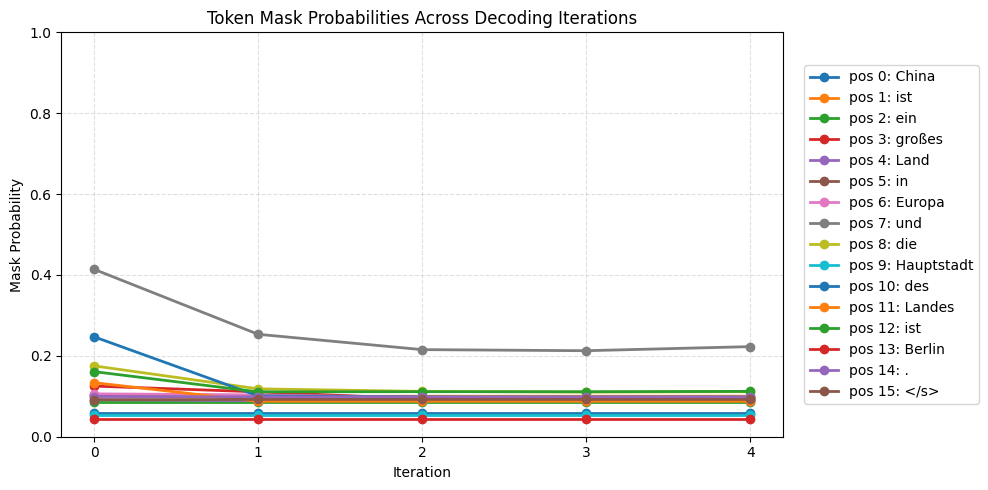

In [283]:
plot_token_mask_probs(decoded_patched_tgt)
